In [25]:
import torch
import matplotlib.pyplot as plt
import os
import torch.nn.functional as F
import torch.nn as nn
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'

In [26]:
def show(activation, *args):
    """
    :param activation:  activation Function exam: torch.sigmoid | torch.tanh | torch.relu
    :return: None
    """

    _, axes = plt.subplots(1, 2)
    x = torch.linspace(-20, 20, 1000) # shape: [1000]
    y = activation(x)

    func_name = activation.__name__
    axes[0].plot(x, y)
    axes[0].grid()
    axes[0].set_title(func_name)

    x = torch.linspace(-20, 20, 1000, requires_grad=True)
    # print(activation(x, *args).sum())
    # 对于 y = f(x)，其中 x = [x1, x2, ..., xn]
    # sum(y) = f(x1) + f(x2) + ... + f(xn)
    # ∂sum(y)/∂xi = f'(xi)  (因为其他项对 xi 的偏导为 0)
    activation(x, *args).sum().backward()

    axes[1].plot(x.detach(), x.grad)
    axes[1].grid()
    axes[1].set_title(f"{func_name}'s Derived")
    plt.show()

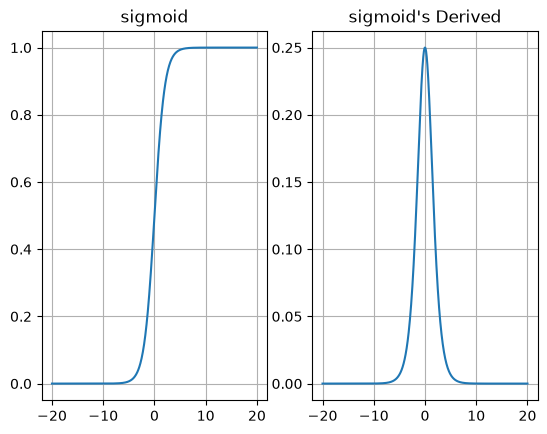

In [27]:
show(torch.sigmoid)

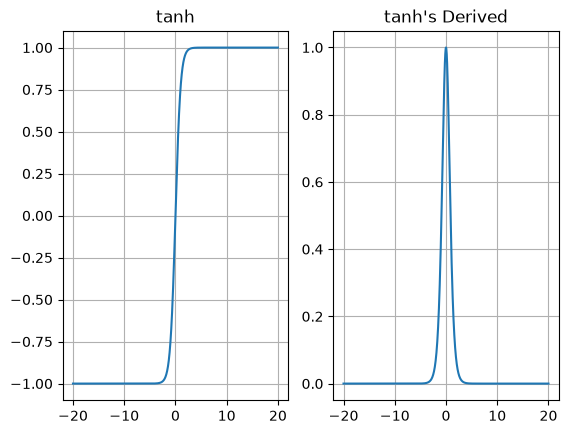

In [28]:
show(torch.tanh)

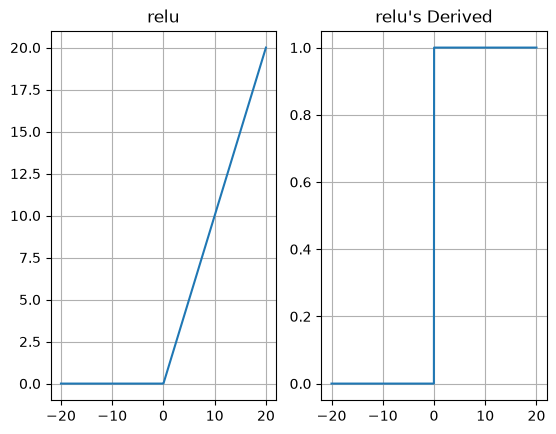

In [29]:
show(torch.relu)

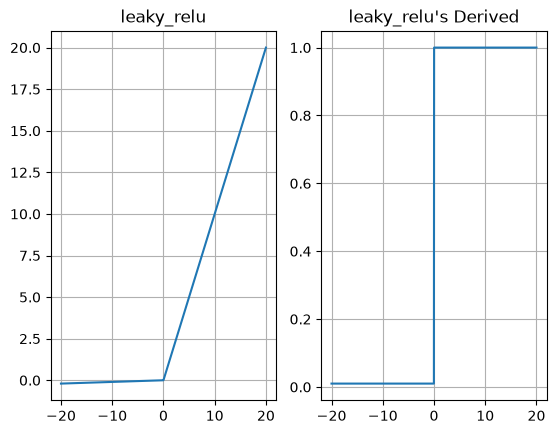

In [30]:
show(F.leaky_relu,1e-2)

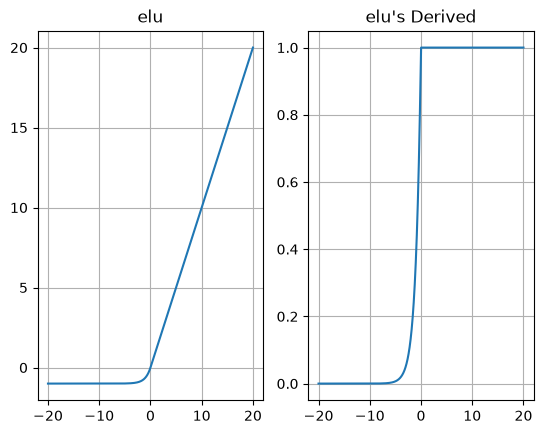

In [31]:
show(F.elu)

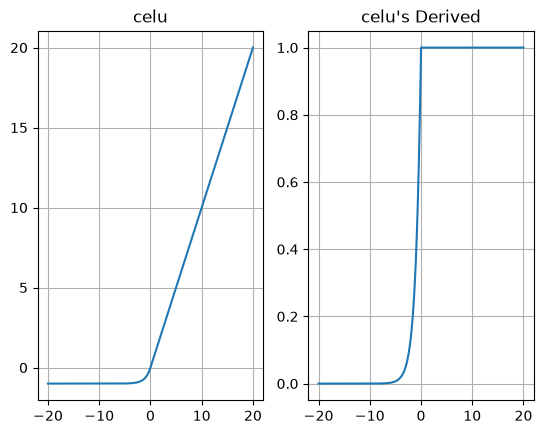

In [32]:
show(torch.celu)

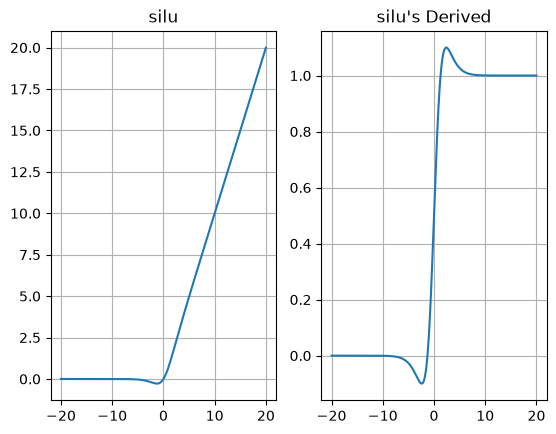

In [33]:
show(F.silu)

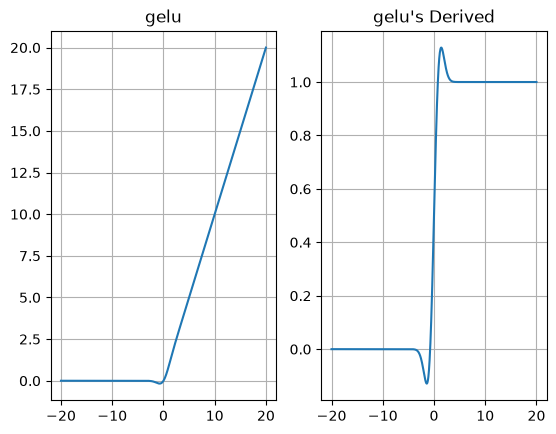

In [34]:
show(F.gelu)

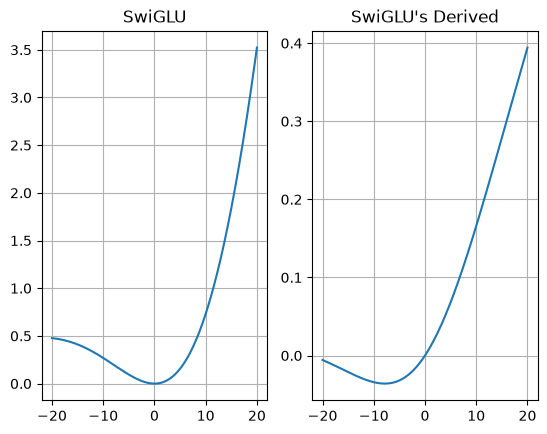

In [82]:

class SwiGLU(nn.Module):
    def __init__(self, dim, hidden_dim):
        super().__init__()
        # 将 gate 和 value 的权重拼成一个大的线性层
        # 输出维度是 2 * hidden_dim
        self.gate_value_proj = nn.Linear(dim, 2 * hidden_dim, bias=False)

        self.out_proj = nn.Linear(hidden_dim, dim, bias=False)

        ## 参数初始化
        nn.init.constant_(self.gate_value_proj.weight,0.1)
        nn.init.constant_(self.out_proj.weight,1)

    def forward(self, x):
        # 一次矩阵乘法得到 gate 和 value 的拼接
        gate_value = self.gate_value_proj(x)
        # 在最后一个维度上拆分成两半
        gate, value = gate_value.chunk(2, dim=-1)
        # 应用门控
        return self.out_proj(F.silu(gate) * value)
## show SwiGLU
def show_SwiGLU():
    swi_glu = SwiGLU(1,1)
    x = torch.linspace(-20, 20, 1000).reshape(-1,1) # shape (1000,1)
    y = swi_glu(x).detach().numpy()

    _, axes = plt.subplots(1, 2)
    axes[0].plot(x, y)
    axes[0].grid()
    axes[0].set_title('SwiGLU')


    x = torch.linspace(-20, 20, 1000,requires_grad=True).reshape(-1,1) # shape (1000,1)
    x.retain_grad()
    swi_glu(x).sum().backward()
    axes[1].plot(x.detach().numpy().reshape(-1), x.grad)
    axes[1].grid()
    axes[1].set_title("SwiGLU's Derived")
    plt.show()


show_SwiGLU()